In [ ]:
!pip install datasets transformers matplotlib seaborn -q

In [ ]:
# Cài đặt thư viện
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from transformers import AutoTokenizer
import torch
from torch.utils.data import DataLoader

# Tải GLUE MNLI
raw_datasets = load_dataset("nyu-mll/glue", "mnli")

print("--- KÍCH THƯỚC TOÀN BỘ DATASET GỐC ---")
print(f"Tập Huấn luyện (Train):          {raw_datasets['train'].num_rows:,} mẫu")
print(f"Tập Kiểm định trùng miền (Val Matched):    {raw_datasets['validation_matched'].num_rows:,} mẫu")
print(f"Tập Kiểm định lệch miền (Val Mismatched): {raw_datasets['validation_mismatched'].num_rows:,} mẫu")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

mnli/train-00000-of-00001.parquet:   0%|          | 0.00/52.2M [00:00<?, ?B/s]

mnli/validation_matched-00000-of-00001.p(…):   0%|          | 0.00/1.21M [00:00<?, ?B/s]

mnli/validation_mismatched-00000-of-0000(…):   0%|          | 0.00/1.25M [00:00<?, ?B/s]

...

Generating validation_matched split:   0%|          | 0/9815 [00:00<?, ? examples/s]

Generating validation_mismatched split:   0%|          | 0/9832 [00:00<?, ? examples/s]

Generating test_matched split:   0%|          | 0/9796 [00:00<?, ? examples/s]

Generating test_mismatched split:   0%|          | 0/9847 [00:00<?, ? examples/s]

--- KÍCH THƯỚC TOÀN BỘ DATASET GỐC ---
Tập Huấn luyện (Train):          392,702 mẫu
Tập Kiểm định trùng miền (Val Matched):    9,815 mẫu
Tập Kiểm định lệch miền (Val Mismatched): 9,832 mẫu


Chuyển toàn bộ dữ liệu dạng Arrow của Hugging Face sang Pandas DataFrame

In [ ]:
# %%
# Chuyển đổi dữ liệu sang Pandas DataFrame
print("Đang cấu trúc lại dữ liệu sang dạng bảng...")
train_df = raw_datasets["train"].to_pandas()
val_matched_df = raw_datasets["validation_matched"].to_pandas()
val_mismatched_df = raw_datasets["validation_mismatched"].to_pandas()

# Ánh xạ nhãn số sang định dạng ngữ nghĩa
label_mapping = {0: "Entailment (Hệ quả)", 1: "Neutral (Trung hòa)", 2: "Contradiction (Mâu thuẫn)"}

print("\n--- CẤU TRÚC ĐỊNG DẠNG CỦA MỘT DÒNG DỮ LIỆU ---")
print(train_df.info())

print("\n--- QUAN SÁT NGẪU NHIÊN 3 CẶP CÂU TRONG TẬP TRAIN ---")
for i in range(3):
    idx = np.random.randint(0, len(train_df))
    print(f"\nMẫu thứ {idx}:")
    print(f"  - Premise (Tiền đề): {train_df['premise'].iloc[idx]}")
    print(f"  - Hypothesis (Giả thuyết): {train_df['hypothesis'].iloc[idx]}")
    print(f"  - Nhãn: {train_df['label'].iloc[idx]} -> {label_mapping[train_df['label'].iloc[idx]]}")

Đang cấu trúc lại dữ liệu sang dạng bảng...

--- CẤU TRÚC ĐỊNG DẠNG CỦA MỘT DÒNG DỮ LIỆU ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392702 entries, 0 to 392701
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   premise     392702 non-null  object
 1   hypothesis  392702 non-null  object
 2   label       392702 non-null  int64 
 3   idx         392702 non-null  int32 
dtypes: int32(1), int64(1), object(2)
memory usage: 10.5+ MB
None

--- QUAN SÁT NGẪU NHIÊN 3 CẶP CÂU TRONG TẬP TRAIN ---

Mẫu thứ 345219:
  - Premise (Tiền đề): The grim  The anti-rejection drugs can cause infection and cancer, and since a hand isn't an essential organ, it isn't worth that risk.
  - Hypothesis (Giả thuyết): The feet are not affected by the anti-rejection drug.
  - Nhãn: 1 -> Neutral (Trung hòa)

Mẫu thứ 354520:
  - Premise (Tiền đề): But I suppose you hardly wish to go out to-day, as you only came yesterday."
  - Hypothesis (Giả

EDA - Kiểm tra sự cân bằng phân phối nhãn (Class Distribution)

/tmp/ipykernel_6406/2674449867.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([label_mapping[i] for i in range(3)])


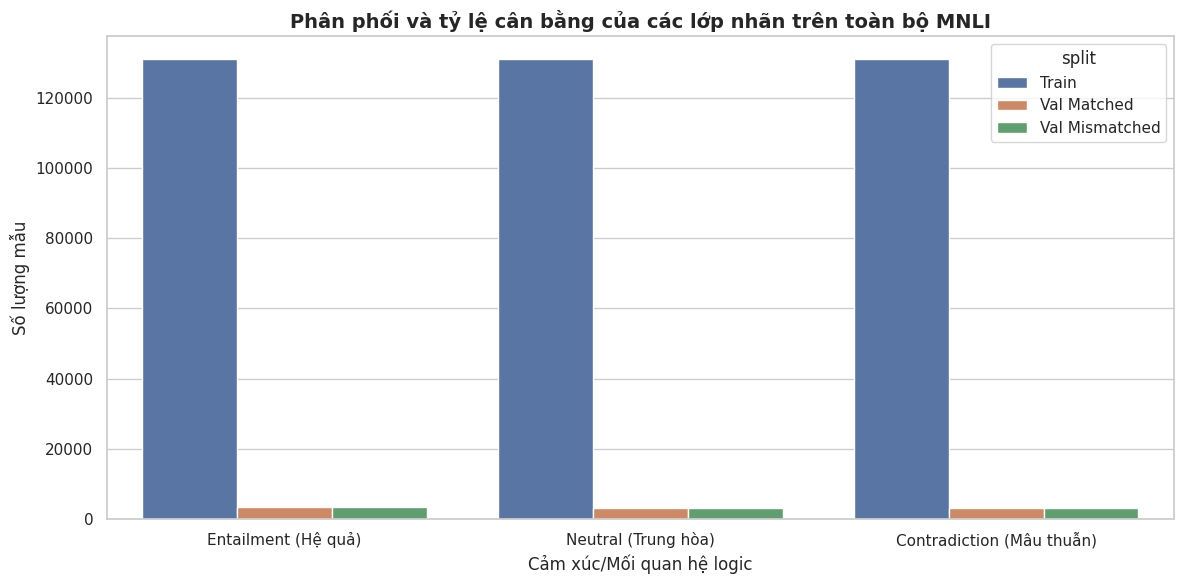

--- TỶ LỆ PHẦN TRĂM CHI TIẾT CÁC LỚP TRÊN TẬP TRAIN (%) ---
label
0    33.332909
1    33.333164
2    33.333928
Name: proportion, dtype: float64


In [ ]:
# %%
# Gộp các tập lại để vẽ biểu đồ so sánh phân phối nhãn
train_df['split'] = 'Train'
val_matched_df['split'] = 'Val Matched'
val_mismatched_df['split'] = 'Val Mismatched'
df_combined = pd.concat([train_df[['label', 'split']], val_matched_df[['label', 'split']], val_mismatched_df[['label', 'split']]])

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Vẽ biểu đồ cột tỷ lệ phần trăm
ax = sns.countplot(data=df_combined, x='label', hue='split', palette='deep')
plt.title('Phân phối và tỷ lệ cân bằng của các lớp nhãn trên toàn bộ MNLI', fontsize=14, fontweight='bold')
plt.xlabel('Cảm xúc/Mối quan hệ logic', fontsize=12)
plt.ylabel('Số lượng mẫu', fontsize=12)
ax.set_xticklabels([label_mapping[i] for i in range(3)])

plt.tight_layout()
plt.show()

# Hiển thị bảng số liệu phần trăm chi tiết để copy vào báo cáo
print("--- TỶ LỆ PHẦN TRĂM CHI TIẾT CÁC LỚP TRÊN TẬP TRAIN (%) ---")
print(train_df['label'].value_counts(normalize=True).sort_index() * 100)

EDA - Thống kê độ dài từ vựng sâu để chọn tham số mạng

Đang tính toán độ dài văn bản thô...


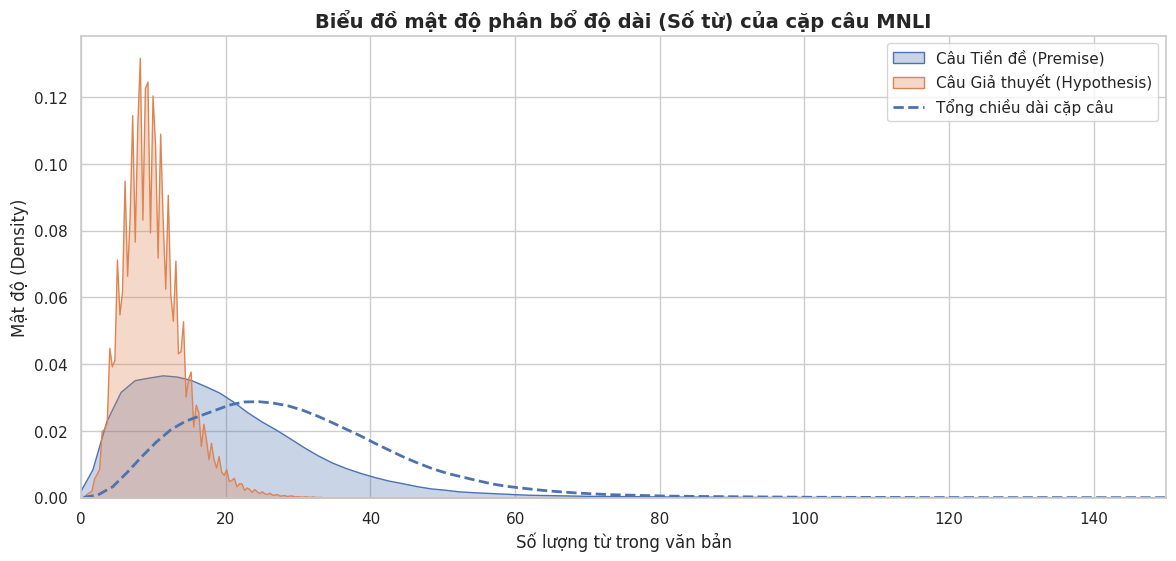

--- THỐNG KÊ PHÂN VỊ ĐỘ DÀI TỔNG CỦA CẶP CÂU ---
Mức Trung vị (50% số câu có độ dài dưới):  27 từ
Mốc 90% số câu trong hệ thống có độ dài dưới: 49 từ
Mốc 95% số câu trong hệ thống có độ dài dưới: 57 từ
Mốc 99% số câu trong hệ thống có độ dài dưới: 81 từ


In [ ]:
# Tính số lượng từ bằng cách chia khoảng trắng trên toàn bộ dữ liệu lớn
print("Đang tính toán độ dài văn bản thô...")
train_df['premise_len'] = train_df['premise'].apply(lambda x: len(str(x).split()))
train_df['hypothesis_len'] = train_df['hypothesis'].apply(lambda x: len(str(x).split()))
train_df['total_len'] = train_df['premise_len'] + train_df['hypothesis_len']

# Vẽ biểu đồ mật độ phân bổ độ dài chuỗi
plt.figure(figsize=(14, 6))
sns.kdeplot(data=train_df['premise_len'], label='Câu Tiền đề (Premise)', fill=True, alpha=0.3)
sns.kdeplot(data=train_df['hypothesis_len'], label='Câu Giả thuyết (Hypothesis)', fill=True, alpha=0.3)
sns.kdeplot(data=train_df['total_len'], label='Tổng chiều dài cặp câu', fill=False, linestyle="--", linewidth=2)

plt.title('Biểu đồ mật độ phân bổ độ dài (Số từ) của cặp câu MNLI', fontsize=14, fontweight='bold')
plt.xlabel('Số lượng từ trong văn bản')
plt.ylabel('Mật độ (Density)')
plt.xlim(0, 150) # Giới hạn trục X để nhìn rõ vùng tập trung dữ liệu
plt.legend()
plt.show()

# Tính toán các chỉ số phân vị cốt lõi
print("--- THỐNG KÊ PHÂN VỊ ĐỘ DÀI TỔNG CỦA CẶP CÂU ---")
percentiles = train_df['total_len'].quantile([0.5, 0.75, 0.90, 0.95, 0.99])
print(f"Mức Trung vị (50% số câu có độ dài dưới):  {percentiles[0.5]:.0f} từ")
print(f"Mốc 90% số câu trong hệ thống có độ dài dưới: {percentiles[0.9]:.0f} từ")
print(f"Mốc 95% số câu trong hệ thống có độ dài dưới: {percentiles[0.95]:.0f} từ")
print(f"Mốc 99% số câu trong hệ thống có độ dài dưới: {percentiles[0.99]:.0f} từ")

Preprocessing

In [ ]:
# %%
# 1. Khởi tạo bộ Tokenizer tương ứng với mô hình Transformer (đang để tạm là BERT-uncased)
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

# 2. Xây dựng hàm mã hóa cặp câu đồng thời
def tokenize_pair_dataset(examples):
    return tokenizer(
        examples["premise"],        # Câu A
        examples["hypothesis"],     # Câu B
        padding="max_length",       # Đệm thêm [PAD] nếu chuỗi ngắn hơn max_length
        truncation=True,             # Cắt bỏ đuôi nếu chuỗi vượt quá max_length
        max_length=128               # Con số tối ưu chứng minh từ kết quả EDA ở Cell 4
    )

print("Bắt đầu quy trình mã hóa Tokenization...")
# Áp dụng song song hóa bằng batched=True để tăng tốc độ xử lý tối đa
tokenized_datasets = raw_datasets.map(tokenize_pair_dataset, batched=True)

# 3. Loại bỏ hoàn toàn các cột chữ thô cấu trúc cũ để giải phóng bộ nhớ RAM
columns_to_drop = ["premise", "hypothesis", "idx"]
tokenized_datasets = tokenized_datasets.remove_columns(columns_to_drop)

# Đổi tên cột 'label' thành 'labels' để đồng bộ với thư viện PyTorch
tokenized_datasets = tokenized_datasets.rename_column("label", "labels")

# 4. Ép định dạng cấu trúc toàn bộ dữ liệu sang PyTorch Tensors
tokenized_datasets.set_format("torch")

print("\nMã hóa thành công!")
print("Cấu trúc các tập dữ liệu số thu được:")
print(tokenized_datasets)

# 5. Tạo các DataLoader hoàn chỉnh phục vụ trực tiếp cho việc huấn luyện sau này
BATCH_SIZE = 32
train_dataloader = DataLoader(tokenized_datasets["train"], shuffle=True, batch_size=BATCH_SIZE)
val_matched_dataloader = DataLoader(tokenized_datasets["validation_matched"], batch_size=BATCH_SIZE)
val_mismatched_dataloader = DataLoader(tokenized_datasets["validation_mismatched"], batch_size=BATCH_SIZE)

# --- TRÍCH XUẤT KIỂM TRA THỬ BATCH ĐẦU TIÊN ---
sample_batch = next(iter(train_dataloader))
print("\n--- KIỂM TRA ĐẦU RA HOÀN CHỈNH CỦA MỘT BATCH NẠP VÀO TRANSFORMER ---")
print(f"Keys: {list(sample_batch.keys())}")
print(f"Shape của Input IDs matrix (X):      {sample_batch['input_ids'].shape} -> [Batch_size, Seq_len]")
print(f"Shape của Attention Mask matrix:     {sample_batch['attention_mask'].shape}")
if 'token_type_ids' in sample_batch:
    print(f"Shape của Token Type IDs (Segment):  {sample_batch['token_type_ids'].shape} -> (Đánh dấu phân tách câu A/B)")
print(f"Shape của Labels vector (Y):         {sample_batch['labels'].shape} -> (Nhãn đích gồm 3 lớp: 0, 1, 2)")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Bắt đầu quy trình mã hóa Tokenization...


...

Map:   0%|          | 0/9815 [00:00<?, ? examples/s]

Map:   0%|          | 0/9832 [00:00<?, ? examples/s]

Map:   0%|          | 0/9796 [00:00<?, ? examples/s]

Map:   0%|          | 0/9847 [00:00<?, ? examples/s]


Mã hóa thành công!
Cấu trúc các tập dữ liệu số thu được:
DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 392702
    })
    validation_matched: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 9815
    })
    validation_mismatched: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 9832
    })
    test_matched: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 9796
    })
    test_mismatched: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 9847
    })
})

--- KIỂM TRA ĐẦU RA HOÀN CHỈNH CỦA MỘT BATCH NẠP VÀO TRANSFORMER ---
Keys: ['labels', 'input_ids', 'token_type_ids', 'attention_mask']
Shape của Input IDs matrix (X):      torch.Size([32, 128]) -> [Batch_size, Seq_len]
Shape c

In [ ]:
# %%
# --- GIỚI HẠN SUBSET ĐỂ TRAIN NHANH ---
from torch.utils.data import Subset

train_dataloader = DataLoader(
    Subset(tokenized_datasets["train"], range(20000)),
    shuffle=True, batch_size=BATCH_SIZE
)

val_matched_dataloader = DataLoader(
    Subset(tokenized_datasets["validation_matched"], range(2000)),
    batch_size=BATCH_SIZE
)

val_mismatched_dataloader = DataLoader(
    Subset(tokenized_datasets["validation_mismatched"], range(2000)),
    batch_size=BATCH_SIZE
)

print(f"✅ Train: {len(train_dataloader)} batches (~20k mẫu)")
print(f"✅ Val Matched: {len(val_matched_dataloader)} batches (~2k mẫu)")

✅ Train: 625 batches (~20k mẫu)
✅ Val Matched: 63 batches (~2k mẫu)


## Xây 2 mô hình cho MNLI (Transformer gốc vs Transformer + SwiGLU MLP)

In [ ]:
# %%
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

def masked_mean_pooling(x: torch.Tensor, attention_mask: torch.Tensor) -> torch.Tensor:
    """
    x: (batch, seq_len, hidden)
    attention_mask: (batch, seq_len) with 1 for real tokens, 0 for PAD
    """
    mask = attention_mask.unsqueeze(-1).to(dtype=x.dtype)  # (batch, seq_len, 1)
    x = x * mask
    denom = mask.sum(dim=1).clamp(min=1.0)
    return x.sum(dim=1) / denom

class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 512):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))  # (1, max_len, d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x + self.pe[:, : x.size(1), :]

class OriginalTransformerMNLI(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        num_classes: int = 3,
        d_model: int = 256,
        nhead: int = 8,
        num_layers: int = 3,
        dim_feedforward: int = 1024,
        dropout: float = 0.1,
        max_len: int = 512,
        type_vocab_size: int = 2,
    ):
        super().__init__()
        self.word_embedding = nn.Embedding(vocab_size, d_model)
        self.type_embedding = nn.Embedding(type_vocab_size, d_model)
        self.pos_encoder = PositionalEncoding(d_model, max_len=max_len)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(d_model, num_classes)

    def forward(
        self,
        input_ids: torch.Tensor,
        attention_mask: torch.Tensor | None = None,
        token_type_ids: torch.Tensor | None = None,
    ) -> torch.Tensor:
        if attention_mask is None:
            attention_mask = torch.ones_like(input_ids)
        if token_type_ids is None:
            token_type_ids = torch.zeros_like(input_ids)

        x = self.word_embedding(input_ids) + self.type_embedding(token_type_ids)
        x = self.pos_encoder(x)

        key_padding_mask = attention_mask == 0  # True = PAD
        x = self.encoder(x, src_key_padding_mask=key_padding_mask)

        pooled = masked_mean_pooling(x, attention_mask)
        pooled = self.dropout(pooled)
        return self.classifier(pooled)

class SwiGLU(nn.Module):
    def __init__(self, in_features: int, hidden_features: int):
        super().__init__()
        self.w1 = nn.Linear(in_features, hidden_features)
        self.w2 = nn.Linear(in_features, hidden_features)
        self.w3 = nn.Linear(hidden_features, in_features)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        swish_out = F.silu(self.w1(x))
        return self.w3(swish_out * self.w2(x))

class SwiGLUTransformerEncoderLayer(nn.Module):
    def __init__(self, d_model: int, nhead: int, dim_feedforward: int = 1024, dropout: float = 0.1):
        super().__init__()
        self.self_attn = nn.MultiheadAttention(d_model, nhead, dropout=dropout, batch_first=True)
        self.mlp = SwiGLU(in_features=d_model, hidden_features=dim_feedforward)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(
        self,
        src: torch.Tensor,
        src_key_padding_mask: torch.Tensor | None = None,
        is_causal: bool = False,
    ) -> torch.Tensor:
        attn_out, _ = self.self_attn(
            src, src, src,
            key_padding_mask=src_key_padding_mask,
            need_weights=False,
            is_causal=is_causal,
        )
        src = self.norm1(src + self.dropout(attn_out))
        mlp_out = self.mlp(src)
        src = self.norm2(src + self.dropout(mlp_out))
        return src

class SwiGLUTransformerMNLI(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        num_classes: int = 3,
        d_model: int = 256,
        nhead: int = 8,
        num_layers: int = 3,
        dim_feedforward: int = 1024,
        dropout: float = 0.1,
        max_len: int = 512,
        type_vocab_size: int = 2,
    ):
        super().__init__()
        self.word_embedding = nn.Embedding(vocab_size, d_model)
        self.type_embedding = nn.Embedding(type_vocab_size, d_model)
        self.pos_encoder = PositionalEncoding(d_model, max_len=max_len)
        self.layers = nn.ModuleList([
            SwiGLUTransformerEncoderLayer(d_model, nhead, dim_feedforward, dropout)
            for _ in range(num_layers)
        ])
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(d_model, num_classes)

    def forward(
        self,
        input_ids: torch.Tensor,
        attention_mask: torch.Tensor | None = None,
        token_type_ids: torch.Tensor | None = None,
    ) -> torch.Tensor:
        if attention_mask is None:
            attention_mask = torch.ones_like(input_ids)
        if token_type_ids is None:
            token_type_ids = torch.zeros_like(input_ids)

        x = self.word_embedding(input_ids) + self.type_embedding(token_type_ids)
        x = self.pos_encoder(x)

        key_padding_mask = attention_mask == 0  # True = PAD
        for layer in self.layers:
            x = layer(x, src_key_padding_mask=key_padding_mask)

        pooled = masked_mean_pooling(x, attention_mask)
        pooled = self.dropout(pooled)
        return self.classifier(pooled)

In [ ]:

# Hyperparameters gợi ý (có thể tinh chỉnh sau)
NUM_CLASSES = 3
VOCAB_SIZE = tokenizer.vocab_size  # phù hợp BERT tokenizer
D_MODEL = 256
N_HEAD = 8
NUM_LAYERS = 3
DIM_FEEDFORWARD = 1024
DROPOUT = 0.1

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

model_original = OriginalTransformerMNLI(
    vocab_size=VOCAB_SIZE,
    num_classes=NUM_CLASSES,
    d_model=D_MODEL,
    nhead=N_HEAD,
    num_layers=NUM_LAYERS,
    dim_feedforward=DIM_FEEDFORWARD,
    dropout=DROPOUT,
    max_len=128,
).to(device)

model_swiglu = SwiGLUTransformerMNLI(
    vocab_size=VOCAB_SIZE,
    num_classes=NUM_CLASSES,
    d_model=D_MODEL,
    nhead=N_HEAD,
    num_layers=NUM_LAYERS,
    dim_feedforward=DIM_FEEDFORWARD,
    dropout=DROPOUT,
    max_len=128,
).to(device)

print(f"#Params Original: {sum(p.numel() for p in model_original.parameters() if p.requires_grad):,}")
print(f"#Params SwiGLU  : {sum(p.numel() for p in model_swiglu.parameters() if p.requires_grad):,}")

# Quick sanity check: forward pass 1 batch
batch = next(iter(train_dataloader))
input_ids = batch["input_ids"].to(device)
attention_mask = batch["attention_mask"].to(device)
token_type_ids = batch.get("token_type_ids")
if token_type_ids is not None:
    token_type_ids = token_type_ids.to(device)

with torch.no_grad():
    logits_o = model_original(input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids)
    logits_s = model_swiglu(input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids)

print("Logits shape (Original):", logits_o.shape)  # (batch, 3)
print("Logits shape (SwiGLU)  :", logits_s.shape)  # (batch, 3)

Device: cuda
#Params Original: 10,184,195
#Params SwiGLU  : 10,973,699
Logits shape (Original): torch.Size([32, 3])
Logits shape (SwiGLU)  : torch.Size([32, 3])


### Chạy huấn luyện (Train) cho cả 2 mô hình. Tinh chỉnh siêu tham số. Ghi nhận các chỉ số Accuracy, Loss, F1-Score.

In [ ]:
# %%
# --- TRAINING FUNCTIONS ---

import copy
from sklearn.metrics import accuracy_score, f1_score, classification_report
import torch
import torch.nn as nn

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, all_preds, all_labels = 0.0, [], []

    for batch in loader:
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        token_type_ids = batch.get("token_type_ids")
        if token_type_ids is not None:
            token_type_ids = token_type_ids.to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()
        logits = model(input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids)
        loss   = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * input_ids.size(0)
        preds = logits.argmax(dim=-1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    return avg_loss, acc, f1


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            token_type_ids = batch.get("token_type_ids")
            if token_type_ids is not None:
                token_type_ids = token_type_ids.to(device)
            labels = batch["labels"].to(device)

            logits = model(input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids)
            loss   = criterion(logits, labels)

            total_loss += loss.item() * input_ids.size(0)
            preds = logits.argmax(dim=-1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    return avg_loss, acc, f1, all_preds, all_labels


def run_training(model, model_name, train_loader, val_loader,
                 num_epochs=5, lr=3e-4, device=None):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-2)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    history = {
        "train_loss": [], "train_acc": [], "train_f1": [],
        "val_loss":   [], "val_acc":   [], "val_f1":   []
    }
    best_val_f1    = 0.0
    best_model_wts = copy.deepcopy(model.state_dict())

    # Early stopping
    patience   = 3
    no_improve = 0

    print(f"\n{'='*65}")
    print(f"  BẮT ĐẦU HUẤN LUYỆN: {model_name}")
    print(f"{'='*65}")
    print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Train Acc':>9} | {'Train F1':>8} | {'Val Loss':>9} | {'Val Acc':>8} | {'Val F1':>7}")
    print(f"{'-'*75}")

    for epoch in range(1, num_epochs + 1):
        tr_loss, tr_acc, tr_f1 = train_one_epoch(model, train_loader, optimizer, criterion, device)
        vl_loss, vl_acc, vl_f1, _, _ = evaluate(model, val_loader, criterion, device)
        scheduler.step()

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["train_f1"].append(tr_f1)
        history["val_loss"].append(vl_loss)
        history["val_acc"].append(vl_acc)
        history["val_f1"].append(vl_f1)

        if vl_f1 > best_val_f1:
            best_val_f1    = vl_f1
            best_model_wts = copy.deepcopy(model.state_dict())
            no_improve     = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"Dừng sớm ở Epoch {epoch} vì không có cải thiện trong {patience} epochs.")
                break

        print(f"{epoch:>6} | {tr_loss:>10.4f} | {tr_acc:>9.4f} | {tr_f1:>8.4f} | {vl_loss:>9.4f} | {vl_acc:>8.4f} | {vl_f1:>7.4f}")

    model.load_state_dict(best_model_wts)
    print(f"✅ Best Val F1 ({model_name}): {best_val_f1:.4f}")
    return history

In [ ]:
# %%
# --- TINH CHỈNH SIÊU THAM SỐ ---
configs = [
    {"lr": 3e-4, "d_model": 256, "num_layers": 3, "dropout": 0.1},
    {"lr": 1e-4, "d_model": 256, "num_layers": 3, "dropout": 0.3},
    {"lr": 3e-4, "d_model": 128, "num_layers": 2, "dropout": 0.2},
]

tuning_results = []

for cfg in configs:
    model_tmp = OriginalTransformerMNLI(
        vocab_size=VOCAB_SIZE, num_classes=NUM_CLASSES,
        d_model=cfg["d_model"], nhead=4 if cfg["d_model"] == 128 else 8,
        num_layers=cfg["num_layers"], dim_feedforward=cfg["d_model"] * 4,
        dropout=cfg["dropout"], max_len=128
    ).to(device)

    hist = run_training(model_tmp,
                        f"lr={cfg['lr']} d={cfg['d_model']} drop={cfg['dropout']}",
                        train_dataloader, val_matched_dataloader,
                        num_epochs=3, lr=cfg["lr"])

    best_f1 = max(hist["val_f1"])
    tuning_results.append({**cfg, "best_val_f1": best_f1})

print("\n" + "="*65)
print("  BẢNG SO SÁNH SIÊU THAM SỐ")
print("="*65)
print(f"{'lr':>8} | {'d_model':>7} | {'layers':>6} | {'dropout':>7} | {'Best Val F1':>11}")
print("-"*55)
for r in tuning_results:
    mark = " ← TỐT NHẤT" if r["best_val_f1"] == max(x["best_val_f1"] for x in tuning_results) else ""
    print(f"{r['lr']:>8} | {r['d_model']:>7} | {r['num_layers']:>6} | {r['dropout']:>7} | {r['best_val_f1']:>11.4f}{mark}")


  BẮT ĐẦU HUẤN LUYỆN: lr=0.0003 d=256 drop=0.1
 Epoch | Train Loss | Train Acc | Train F1 |  Val Loss |  Val Acc |  Val F1
---------------------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


     1 |     1.0746 |    0.4184 |   0.4102 |    1.0354 |   0.4765 |  0.4675
     2 |     1.0043 |    0.4904 |   0.4791 |    1.0157 |   0.4950 |  0.4790
     3 |     0.9370 |    0.5504 |   0.5435 |    1.0336 |   0.4870 |  0.4879
✅ Best Val F1 (lr=0.0003 d=256 drop=0.1): 0.4879

  BẮT ĐẦU HUẤN LUYỆN: lr=0.0001 d=256 drop=0.3
 Epoch | Train Loss | Train Acc | Train F1 |  Val Loss |  Val Acc |  Val F1
---------------------------------------------------------------------------
     1 |     1.0842 |    0.4051 |   0.3959 |    1.0532 |   0.4260 |  0.4239
     2 |     1.0199 |    0.4678 |   0.4603 |    1.0214 |   0.4575 |  0.4582
     3 |     0.9826 |    0.5085 |   0.5014 |    1.0117 |   0.4895 |  0.4715
✅ Best Val F1 (lr=0.0001 d=256 drop=0.3): 0.4715

  BẮT ĐẦU HUẤN LUYỆN: lr=0.0003 d=128 drop=0.2
 Epoch | Train Loss | Train Acc | Train F1 |  Val Loss |  Val Acc |  Val F1
---------------------------------------------------------------------------
     1 |     1.0670 |    0.4164 |   0.4062 |  

In [ ]:
# %%
# --- FINAL TRAINING VỚI CONFIG TỐT NHẤT ---
# (Sau khi xem bảng trên, cập nhật BEST_LR và BEST_DROPOUT tương ứng)
BEST_LR      = 3e-4
NUM_EPOCHS   = 10

history_original = run_training(model_original, "Original Transformer",
                                train_dataloader, val_matched_dataloader,
                                num_epochs=NUM_EPOCHS, lr=BEST_LR, device=device)

history_swiglu   = run_training(model_swiglu, "SwiGLU Transformer",
                                train_dataloader, val_matched_dataloader,
                                num_epochs=NUM_EPOCHS, lr=BEST_LR, device=device)


  BẮT ĐẦU HUẤN LUYỆN: Original Transformer
 Epoch | Train Loss | Train Acc | Train F1 |  Val Loss |  Val Acc |  Val F1
---------------------------------------------------------------------------
     1 |     1.0676 |    0.4193 |   0.4069 |    1.0457 |   0.4690 |  0.4181
     2 |     1.0064 |    0.4805 |   0.4685 |    0.9946 |   0.5025 |  0.4667
     3 |     0.9700 |    0.5188 |   0.5080 |    0.9881 |   0.5110 |  0.4913
     4 |     0.9212 |    0.5606 |   0.5517 |    0.9867 |   0.5130 |  0.5070
     5 |     0.8527 |    0.6085 |   0.6025 |    1.0279 |   0.5080 |  0.4992
     6 |     0.7581 |    0.6685 |   0.6631 |    1.0678 |   0.5025 |  0.5023
Dừng sớm ở Epoch 7 vì không có cải thiện trong 3 epochs.
✅ Best Val F1 (Original Transformer): 0.5070

  BẮT ĐẦU HUẤN LUYỆN: SwiGLU Transformer
 Epoch | Train Loss | Train Acc | Train F1 |  Val Loss |  Val Acc |  Val F1
---------------------------------------------------------------------------
     1 |     1.0568 |    0.4303 |   0.4224 |    1.01

In [ ]:
# --- BÁO CÁO KẾT QUẢ CUỐI ---
label_names = ["Entailment", "Neutral", "Contradiction"]

def final_report(model, model_name, loader, device):
    criterion = nn.CrossEntropyLoss()
    loss, acc, f1, preds, labels = evaluate(model, loader, criterion, device)
    print(f"\n{'='*60}")
    print(f"  KẾT QUẢ: {model_name}")
    print(f"{'='*60}")
    print(f"  Val Loss : {loss:.4f}")
    print(f"  Val Acc  : {acc:.4f} ({acc*100:.2f}%)")
    print(f"  Val F1   : {f1:.4f} (macro)")
    print(f"\n--- Chi tiết từng nhãn ---")
    print(classification_report(labels, preds, target_names=label_names, zero_division=0))

final_report(model_original, "Original Transformer", val_matched_dataloader, device)
final_report(model_swiglu,   "SwiGLU Transformer",   val_matched_dataloader, device)


  KẾT QUẢ: Original Transformer
  Val Loss : 0.9867
  Val Acc  : 0.5130 (51.30%)
  Val F1   : 0.5070 (macro)

--- Chi tiết từng nhãn ---
               precision    recall  f1-score   support

   Entailment       0.47      0.68      0.55       697
      Neutral       0.46      0.43      0.44       607
Contradiction       0.69      0.43      0.53       696

     accuracy                           0.51      2000
    macro avg       0.54      0.51      0.51      2000
 weighted avg       0.54      0.51      0.51      2000


  KẾT QUẢ: SwiGLU Transformer
  Val Loss : 1.1480
  Val Acc  : 0.5225 (52.25%)
  Val F1   : 0.5186 (macro)

--- Chi tiết từng nhãn ---
               precision    recall  f1-score   support

   Entailment       0.53      0.51      0.52       697
      Neutral       0.45      0.44      0.45       607
Contradiction       0.58      0.61      0.59       696

     accuracy                           0.52      2000
    macro avg       0.52      0.52      0.52      2000
 weigh

### So sánh 2 mô hình

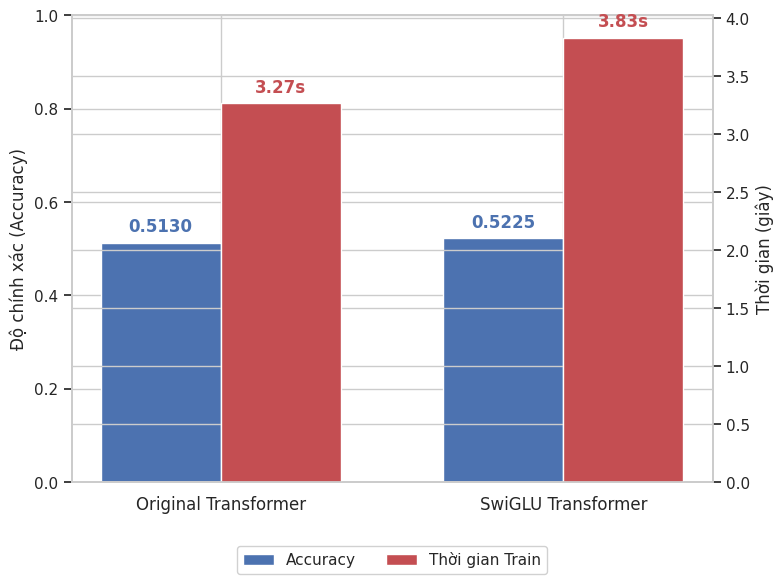

In [ ]:
import time
import matplotlib.pyplot as plt
import numpy as np
import torch

# Lấy độ chính xác tốt nhất (Validation Accuracy) từ history
acc_original = max(history_original["val_acc"])
acc_swiglu = max(history_swiglu["val_acc"])

# Hàm đo lường thời gian huấn luyện
def measure_train_time(model, dataloader, num_batches=100):
  model.train()
  criterion = torch.nn.CrossEntropyLoss()
  optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)

  start_time = time.time()
  for i, batch in enumerate(dataloader):
        if i >= num_batches:
            break
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        token_type_ids = batch.get("token_type_ids")
        if token_type_ids is not None:
            token_type_ids = token_type_ids.to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()
        logits = model(input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

  return time.time() - start_time

time_original = measure_train_time(model_original, train_dataloader)
time_swiglu = measure_train_time(model_swiglu, train_dataloader)

# --- BIỂU ĐỒ SO SÁNH ---
labels = ['Original Transformer', 'SwiGLU Transformer']
acc_scores = [acc_original, acc_swiglu]
times = [time_original, time_swiglu]

fig, ax1 = plt.subplots(figsize=(8, 6))

# Cột cho độ chính xác (Accuracy)
bar_width = 0.35
x = np.arange(len(labels))
rects1 = ax1.bar(x - bar_width/2, acc_scores, bar_width, label='Accuracy', color='#4C72B0')

ax1.set_ylabel('Độ chính xác (Accuracy)')
ax1.set_ylim(0, 1.0)
ax1.set_xticks(x)
ax1.set_xticklabels(labels, fontsize=12)

# Cột cho thời gian huấn luyện
ax2 = ax1.twinx()
rects2 = ax2.bar(x + bar_width/2, times, bar_width, label='Thời gian Train', color='#C44E52')
ax2.set_ylabel('Thời gian (giây)')

# Thêm tiêu đề và chú thích
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

# Đặt chú thích nằm ở giữa, ngay dưới đáy biểu đồ (ngoài vùng hiển thị cột)
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=2, framealpha=0.9)

# Ghi chú chỉ số trực tiếp lên các cột
for rect in rects1:
    height = rect.get_height()
    ax1.annotate(f'{height:.4f}', xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 5), textcoords="offset points", ha='center', va='bottom', color='#4C72B0', fontweight='bold')

for rect in rects2:
    height = rect.get_height()
    ax2.annotate(f'{height:.2f}s', xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 5), textcoords="offset points", ha='center', va='bottom', color='#C44E52', fontweight='bold')

plt.tight_layout()
plt.show()